이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- torchinfo
- numpy
- matplotlib

예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)


In [1]:
# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()


- 다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
- 공통 라이브러리의 `set_seed()` 함수(6장부터 사용)는 지금까지 사용한 파이썬 표준 라이브러리, 파이토치, 넘파이의 난수 발생 초기화를 묶어서 실행하는 함수이다.


In [2]:
SEED = 42
common.set_seed(SEED)

42

- device: 실습 환경에 맞는 하드웨어 가속기 장치 객체
- 공통 라이브러리의 get_device() 함수 사용

In [3]:
device = common.get_device()

CUDA를 사용합니다.


# 6-2 순서를 예측하는 생성 모델 만들기

본 노트북은 본문 6-2절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 단순 RNN(`nn.RNN`)으로 순환 신경망 모델 정의
- 데이터에서 어휘 사전을 자동으로 만들고 데이터셋 구성
- 다음 토큰 예측과 이어 붙이기로 순차 데이터 생성

본문의 모델 7의 구현에 해당되며, 모델 7의 제시문은 다음과 같다.

> **모델 7. 작은별 변주기**
>
> 순환 신경망 모델을 <반짝반짝 작은별>의 멜로디로 학습시켜, 마중물 멜로디가 제시되면 여기에 이어서 <반짝반짝 작은별>과 유사한 멜로디를 생성하는 '작은별 변주기'를 만들어 본다.

## 단순 RNN 모델

- 순환 신경망 모델은 순환 계층과 완전 연결 계층으로 구성한다.
    - `input_size`와 `output_size`는 어휘 사전의 크기와 같아야 한다(여기서는 8).
    - `hidden_size`는 숨겨진 상태 벡터의 크기로, 32를 사용한다.
- `nn.RNN`은 모든 시점의 출력과 마지막 숨겨진 상태를 함께 반환하므로, 필요한 쪽만 골라 완전 연결 계층에 전달한다.

In [4]:
######################################################################################
# 코드 6-5 - 멜로디를 학습하는 단순 RNN 모델의 생성
######################################################################################

import torch.nn as nn

# 단순 RNN 계층을 사용하는 순환 신경망 모델 클래스
class MelodyRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # 단순 RNN 계층 블록
        self.rnn = nn.RNN(
            input_size=input_size,          # 어휘 사전의 크기(각 토큰별 벡터의 크기)
            hidden_size=hidden_size,        # 숨겨진 상태의 크기
            batch_first=True                # (B, S, input_size) 형태의 입력 사용
        )
        # 완전 연결 계층
        #     입력 크기: 숨겨진 상태 텐서의 크기
        #     출력 크기: 어휘 사전 크기(각 토큰별 원-핫 텐서 크기)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):                   # 입력 x: (B, S, input_size) 
        outputs, _ = self.rnn(x)            #      -> (B, S, hidden_size)
        # [:, -1, :] 슬라이싱으로 마지막 시점의 숨겨진 상태만 선택
        last_hidden = outputs[:, -1, :]     #      -> (B, hidden_size)
        # 완전 연결 계층을 통과해 최종 결과 산출
        return self.fc(last_hidden)         #      -> (B, output_size)

In [5]:
# 참고 - 모델 객체 생성과 구조 확인

import torch
from torchinfo import summary

model = MelodyRNN(8, 32, 8)
# 배치 크기(B)가 8, 입력 샘플 순차 데이터의 길이(S)가 4인 경우
# 입력 텐서의 형태 - (B, S, input_size) = (8, 4, 8)
summary(model, input_size=(8, 4, 8), device=torch.device('cpu'))

Layer (type:depth-idx)                   Output Shape              Param #
MelodyRNN                                [8, 8]                    --
├─RNN: 1-1                               [8, 4, 32]                1,344
├─Linear: 1-2                            [8, 8]                    264
Total params: 1,608
Trainable params: 1,608
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.01
Estimated Total Size (MB): 0.02

## 데이터셋 구성

- 6-1절에서는 어휘 사전을 딕셔너리로 직접 정의했지만, 데이터가 많으면 그렇게 하기 어렵다.
    - 데이터에 포함된 토큰에서 중복을 제거한 뒤 고유 번호를 차례로 부여하면 된다.
- 크기가 5인 슬라이딩 윈도우로 이전 네 음에서 다음 음 하나를 예측하는 데이터셋을 만든다.
    - 쉼표(`_`)와 `<eos>` 토큰도 함께 구성한다.

In [6]:
######################################################################################
# 코드 6-6 - MelodyDataset 클래스와 데이터셋, 데이터로더 생성
######################################################################################

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# <반짝반짝 작은별>: 도, 레, 미, 파, 솔, 라의 여섯 음과 쉼표(_)까지 일곱 토큰으로 구성
#   시는 포함되어 있지 않다.
sequence = '도도솔솔라라솔_파파미미레레도_솔솔파파미미레_' \
           '솔솔파파미미레_도도솔솔라라솔_파파미미레레도_'

# 어휘 사전 만들기
EOS_TOKEN = '<eos>'                     # <eos> (순차 데이터의 끝) 특수 토큰
vocab = {EOS_TOKEN: 0}                  # <eos>의 고유 번호: 0
# 데이터에 등장하는 토큰만으로 어휘 사전을 구성('시' 제외)
# 중복 토큰 제거: 리스트 -> set 변환으로 간단하게 중복 제거가 가능
unique_tokens = sorted(set(sequence))   # sorted()로 순서를 고정해 재현성을 확보
for i, token in enumerate(unique_tokens):
    vocab[token] = i + 1
vocab_size = len(vocab)                 # 어휘 사전의 크기

# 데이터셋 클래스 정의
class MelodyDataset(Dataset):
    def __init__(self, sequence, vocab, window_size):
        self.vocab = vocab
        self.window_size = window_size
        # 순차 데이터를 리스트로 변환하고 끝에 <eos> 추가 후, 고유 번호 텐서로 미리 변환
        token_list = list(sequence) + [EOS_TOKEN]
        self.sequence_idx = torch.tensor([vocab[token] for token in token_list])

    def __len__(self):
        # 슬라이딩 윈도우로 만들 수 있는 샘플 수 = 시퀀스 길이 - 윈도우 크기 + 1
        return len(self.sequence_idx) - self.window_size + 1

    # 미리 변환해 둔 고유 번호 텐서에서 idx에 대응하는 윈도우 영역만 분리해 반환
    def __getitem__(self, idx):
        subsequence = self.sequence_idx[idx: idx + self.window_size]
        # 입력: 앞 (window_size - 1)개 토큰을 원-핫 인코딩한 실수형 텐서
        x = F.one_hot(subsequence[:-1], num_classes=len(self.vocab)).float()
        # 정답: 마지막 토큰의 고유 번호(정수형 텐서)
        #     nn.CrossEntropyLoss의 정답은 일반적으로 torch.long 자료형을 사용
        label = subsequence[-1].long()
        return x, label


# 데이터셋과 데이터로더 생성
window_size = 5                         # 입력 길이 4, 정답 길이 1
melody_dataset = MelodyDataset(sequence, vocab, window_size)
BATCH_SIZE = 8                          # 배치 크기
melody_dataloader = DataLoader(melody_dataset, batch_size=BATCH_SIZE, shuffle=True)

print('생성된 어휘 사전:', vocab)
print(f'어휘 사전의 크기: {vocab_size}')
print(f'데이터셋 샘플 수: {len(melody_dataset)}개')
print('마지막 샘플:')               # 마지막 샘플의 정답 - <eos> (tensor(0))
print(melody_dataset[len(melody_dataset) - 1])

생성된 어휘 사전: {'<eos>': 0, '_': 1, '도': 2, '라': 3, '레': 4, '미': 5, '솔': 6, '파': 7}
어휘 사전의 크기: 8
데이터셋 샘플 수: 45개
마지막 샘플:
(tensor([[0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.]]), tensor(0))


- 학습 함수는 1 에포크 학습 함수와 전체 학습 함수로 나눠 구현한다.

In [7]:
# 참고 - 학습 함수(1 에포크 학습 함수와 전체 학습 함수)

# 1 에포크 학습: 가중 평균 훈련 손실을 반환
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 전체 학습 함수
def train(model, data_loader, criterion, optimizer, num_epochs, device=None):
    if device is None:
        device = torch.device('cpu')  # 기본값으로 CPU를 사용하도록 설정

    model.to(device)

    log = common.EpochLogger(num_epochs, columns=('훈련 손실',), formats=('{:.4f}',))
    for epoch in range(1, num_epochs + 1):
        train_loss = train_epoch(model, data_loader, criterion, optimizer, device)
        log.row(epoch, train_loss)
    return log

 에포크    훈련 손실     시간
  1/200       2.0611     0:00


 20/200       1.2443     0:01


 40/200       0.7401     0:01


 60/200       0.5414     0:01


 80/200       0.4141     0:01


...

120/200       0.2766     0:02


140/200       0.2421     0:02


160/200       0.2177     0:03


180/200       0.2010     0:03


200/200       0.1889     0:03


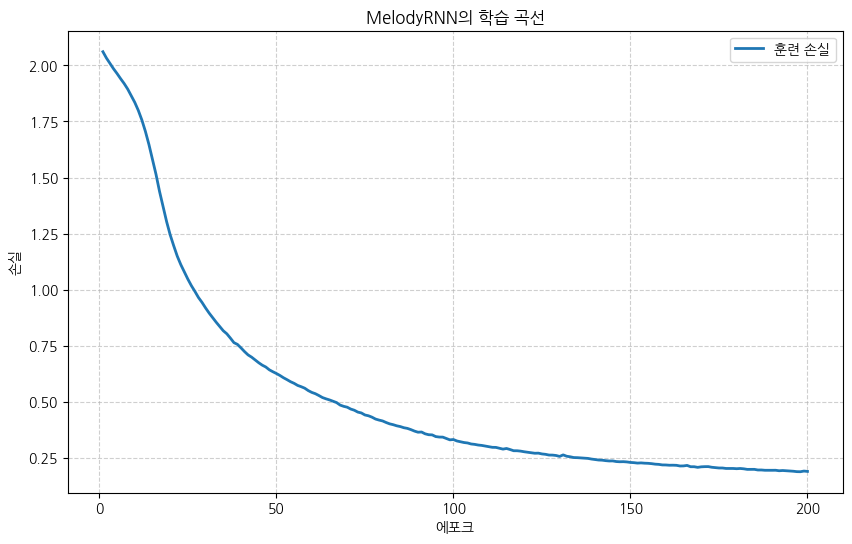

In [8]:
# 참고 - 단순 RNN 모델의 학습

import torch.optim as optim

# 하이퍼파라미터
LR = 0.001                             # 학습률
EPOCHS = 200                           # 전체 학습 에포크

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# 학습 루프: 조기 종료 방식 미적용, device는 미리 구해 둔 장치 객체
log = train(model, melody_dataloader, criterion, optimizer, EPOCHS, device)

# 학습 곡선 시각화
log.plot(title='MelodyRNN의 학습 곡선')

## 멜로디 생성

- 모델의 출력은 클래스별 로짓 텐서이므로 `argmax()`로 가장 점수가 높은 인덱스를 구한다.
    - 어휘 사전을 뒤집은 역방향 어휘 사전으로 인덱스를 토큰으로 되돌린다.

In [9]:
######################################################################################
# 코드 6-7 - 다음 음을 예측하기
######################################################################################

# 마중물(이전 4개의 음)로 다음 음을 예측하는 예측 함수
def predict_next(model, sequence, vocab, reversed_vocab, device=None):
    # 학습 장치가 지정되지 않으면 CPU 사용
    if device is None:
        device = torch.device('cpu')
    if len(sequence) < 4:
        raise ValueError('예측에는 최소 4개의 음이 필요합니다.')
    sequence = sequence[-4:]                # 네 음 이상 입력해도 마지막 네 음으로 예측
    model.eval()
    # 원-핫 인코딩된 (4, 8) 텐서에 배치 차원 추가 -> (1, 4, 8)
    sequence_idx = torch.tensor([vocab[token] for token in sequence])
    input_tensor = F.one_hot(sequence_idx, len(vocab)).float().unsqueeze(0)
    # 예측용 마중물 텐서는 모델과 같은 장치에 위치해야 함
    input_tensor = input_tensor.to(device)
    # 모델 예측 결과(음별 로짓)를 바탕으로 다음 음 예측
    with torch.no_grad():
        prediction = model(input_tensor)
        predicted_idx = torch.argmax(prediction).item()
    # 역방향 어휘 사전으로 토큰을 구해 반환
    return reversed_vocab[predicted_idx]

input_sequence = '도도솔솔'             # 예측을 위한 마중물 음
# 역방향 어휘 사전: 어휘 사전(음 -> 고유번호)의 방향을 바꾼 딕셔너리(고유번호 -> 음)
reversed_vocab = {i: token for token, i in vocab.items()}
next_token = predict_next(model, input_sequence, vocab, reversed_vocab, device)
print(f'다음 음: {next_token}')

다음 음: 라


- 가장 최근 네 음으로 다음 음을 예측하고, 그 결과를 다시 입력에 붙여 이어서 예측하기를 반복하면 원하는 길이의 멜로디를 만들 수 있다.
    - `<eos>` 토큰이 예측되면 그 시점에 생성이 끝났다고 보고 반복을 멈춘다.

In [10]:
######################################################################################
# 코드 6-8 - 정해진 길이의 멜로디를 생성
######################################################################################

# 자기회귀 방식의 생성 함수
# 마중물(start_sequence)로 시작해서 정해진 길이(generated_length)만큼 생성하는 생성
# 종료 토큰(eos_token)을 예측하면 정해진 길이 이전에 생성 종료
def generate_sequence(model, start_sequence, generated_length, vocab, eos_token, device):
    if device is None:
        device = torch.device('cpu')
    reversed_vocab = {i: token for token, i in vocab.items()}
    result = list(start_sequence)
    for _ in range(generated_length):
        next_token = predict_next(model, result[-4:], vocab, reversed_vocab, device)
        result.append(next_token)
        # 생성 도중 <eos>가 나오면 길이와 상관없이 종료
        if eos_token is not None and next_token == eos_token:
            break
    return result

# '반짝반짝 작은별'에 포함된 멜로디로 시작
generated = generate_sequence(model, '도도솔솔', 32, vocab, EOS_TOKEN, device)
print(f"'도도솔솔'로 생성: {''.join(generated)}")

# '반짝반짝 작은별'에 포함되지 않은 멜로디로 시작
generated = generate_sequence(model, '도레미파', 32, vocab, EOS_TOKEN, device)
print(f"'도레미파'로 생성: {''.join(generated)}")

'도도솔솔'로 생성: 도도솔솔라라솔_파파미미레레도_솔솔파파미미레레도_솔솔파파미미레레도_
'도레미파'로 생성: 도레미파파레_레레파파미미레레도_솔솔파파미미레레도_솔솔파파미미레레도


## 정리

- 순환 신경망 모델은 순환 계층과 완전 연결 계층으로 구성하며, 입력과 출력의 크기는 어휘 사전의 크기와 같다.
- `nn.RNN`은 모든 시점의 출력과 마지막 숨겨진 상태를 함께 반환하므로 필요한 쪽을 골라 써야 한다.
- 데이터가 많으면 어휘 사전을 직접 정의하는 대신 데이터에서 토큰을 모아 자동으로 만든다.
- 다음 토큰을 예측해 입력에 이어 붙이기를 반복하면 순차 데이터를 생성할 수 있고, `<eos>`가 나오면 멈춘다.

> 학습 결과의 구체적인 수치는 실행 환경에 따라 본문과 조금씩 다를 수 있다.